<h2>Linear Regression from Scratch — Energy Efficiency</h2>

This notebook builds a **Linear Regression model from scratch using Gradient Descent** and validates it against sklearn's closed-form normal equation implementation.

The dataset comes from a 2012 study by Tsanas & Xifara ([UCI Repository](https://archive.ics.uci.edu/dataset/242/energy+efficiency)) in which 12 building shapes were simulated in Ecotect across variations in glazing, orientation, and surface parameters. The goal is to predict **Heating Load (Y1)** — the energy required to maintain comfortable indoor temperatures — from 8 architectural features.

This is a clean regression problem: no missing values, all numeric features, and a well-understood physical relationship between inputs and target.

In [ ]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

os.getcwd()

<hr>
<h3>1. Dataset Overview</h3>

<b>768 samples &nbsp;|&nbsp; 8 features &nbsp;|&nbsp; 2 targets &nbsp;|&nbsp; No missing values</b><br><br>

<b><u>Features</u></b>
<li><b>X1</b> — Relative Compactness &nbsp;&nbsp;<i>(ratio of building volume to surface area)</i></li>
<li><b>X2</b> — Surface Area &nbsp;&nbsp;<i>(m²)</i></li>
<li><b>X3</b> — Wall Area &nbsp;&nbsp;<i>(m²)</i></li>
<li><b>X4</b> — Roof Area &nbsp;&nbsp;<i>(m²)</i></li>
<li><b>X5</b> — Overall Height &nbsp;&nbsp;<i>(m) — only two values: 3.5m and 7.0m</i></li>
<li><b>X6</b> — Orientation &nbsp;&nbsp;<i>(integer 2–5, encodes N/S/E/W)</i></li>
<li><b>X7</b> — Glazing Area &nbsp;&nbsp;<i>(fraction of floor area)</i></li>
<li><b>X8</b> — Glazing Area Distribution &nbsp;&nbsp;<i>(integer 0–5)</i></li>

<br><b><u>Targets</u></b>
<li><b>Y1</b> — Heating Load &nbsp;&nbsp;<i>(kWh/m²) — our target</i></li>
<li><b>Y2</b> — Cooling Load &nbsp;&nbsp;<i>(kWh/m²) — not used in this notebook</i></li>

In [2]:
data = pd.read_excel('../data/ENB2012_data.xlsx')

# Rename columns from generic X/Y labels to descriptive names
data = data.rename(columns={
    'X1': 'Relative_Compactness',
    'X2': 'Surface_Area',
    'X3': 'Wall_Area',
    'X4': 'Roof_Area',
    'X5': 'Overall_Height',
    'X6': 'Orientation',
    'X7': 'Glazing_Area',
    'X8': 'Glazing_Area_Distribution',
    'Y1': 'Heating_Load',
    'Y2': 'Cooling_Load'
})

data.head(5)

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [3]:
data.dtypes

Relative_Compactness         float64
Surface_Area                 float64
Wall_Area                    float64
Roof_Area                    float64
Overall_Height               float64
Orientation                    int64
Glazing_Area                 float64
Glazing_Area_Distribution      int64
Heating_Load                 float64
Cooling_Load                 float64
dtype: object

In [4]:
data.describe()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307195,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090204,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [5]:
# Unique value counts reveal the simulation structure of the dataset —
# most features take only a handful of fixed values rather than being truly continuous
data.nunique()

Relative_Compactness          12
Surface_Area                  12
Wall_Area                      7
Roof_Area                      4
Overall_Height                 2
Orientation                    4
Glazing_Area                   4
Glazing_Area_Distribution      6
Heating_Load                 587
Cooling_Load                 636
dtype: int64

In [6]:
for col in data.columns.to_list()[:-2]:
    print(f"--- Unique values in '{col}' ---")
    print(data[col].unique())
    print("\n")

--- Unique values in 'Relative_Compactness' ---
[0.98 0.9  0.86 0.82 0.79 0.76 0.74 0.71 0.69 0.66 0.64 0.62]


--- Unique values in 'Surface_Area' ---
[514.5 563.5 588.  612.5 637.  661.5 686.  710.5 735.  759.5 784.  808.5]


--- Unique values in 'Wall_Area' ---
[294.  318.5 343.  416.5 245.  269.5 367.5]


--- Unique values in 'Roof_Area' ---
[110.25 122.5  147.   220.5 ]


--- Unique values in 'Overall_Height' ---
[7.  3.5]


--- Unique values in 'Orientation' ---
[2 3 4 5]


--- Unique values in 'Glazing_Area' ---
[0.   0.1  0.25 0.4 ]


--- Unique values in 'Glazing_Area_Distribution' ---
[0 1 2 3 4 5]




<hr>
<h3>2. Exploratory Data Analysis</h3>

For regression EDA the four things that matter most are:
<li><b>Target distribution</b> — is Y1 roughly normal? Skewed or multimodal targets can signal model limitations</li>
<li><b>Feature-target relationships</b> — are the relationships linear? High correlation = strong predictors</li>
<li><b>Feature scale</b> — matters for gradient descent convergence; irrelevant for the normal equation</li>
<li><b>Multicollinearity</b> — highly correlated features make X^T X near-singular and destabilize the normal equation</li>

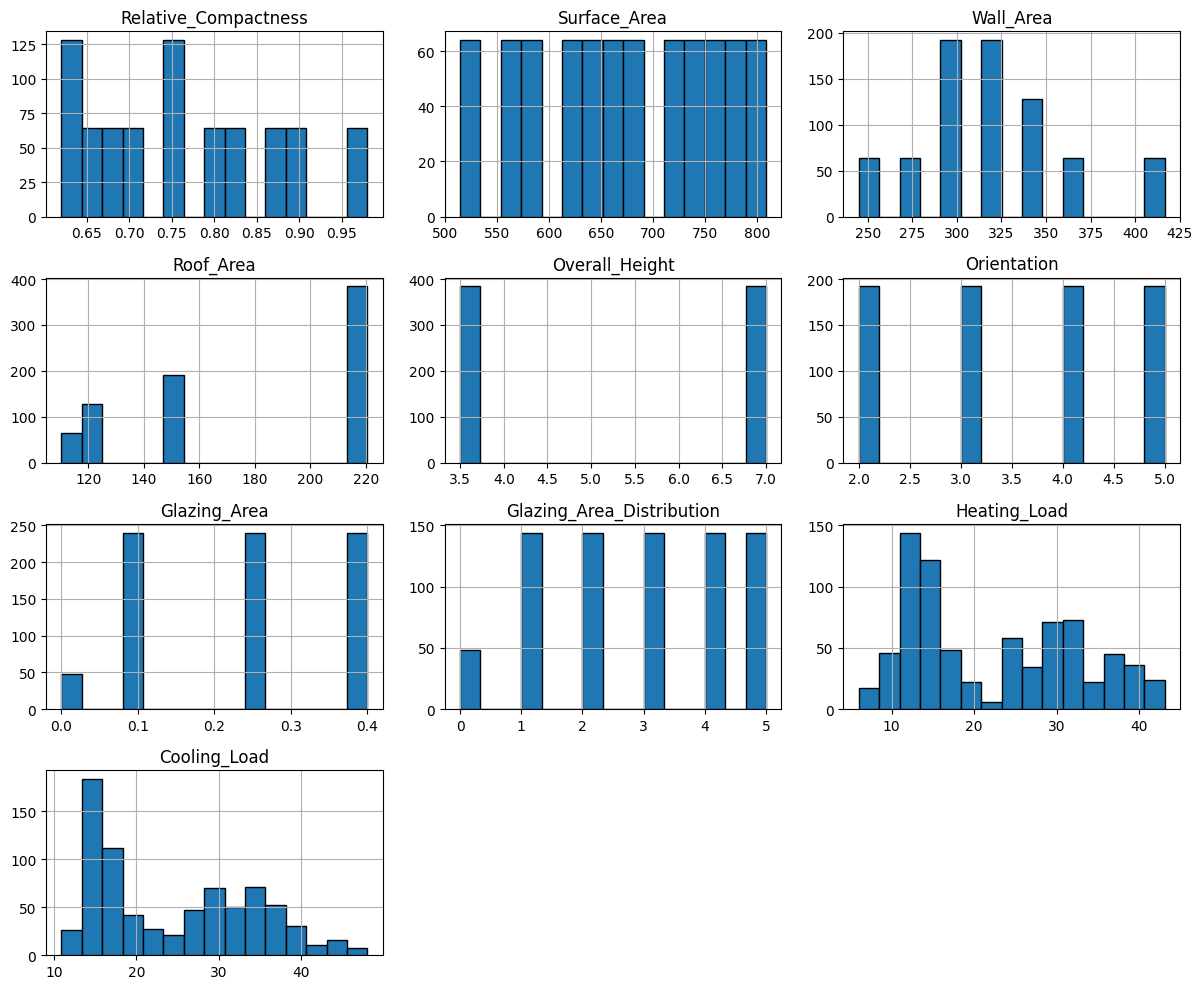

In [7]:
# Histogram grid — checking distributions of all features and both targets
# Key observations:
# - Features appear 'skewed' but are actually discrete — this is a simulation dataset with fixed parameter values
# - X5 (Overall Height) is effectively binary: only 3.5m and 7.0m
# - X6 (Orientation) is uniform — 4 equal categories, unlikely to carry predictive signal
# - Y1 (Heating Load) is bimodal — strongly suggesting two sub-populations driven by building height
data.hist(bins=15, figsize=(12, 10), edgecolor='black')
plt.tight_layout()
plt.show()

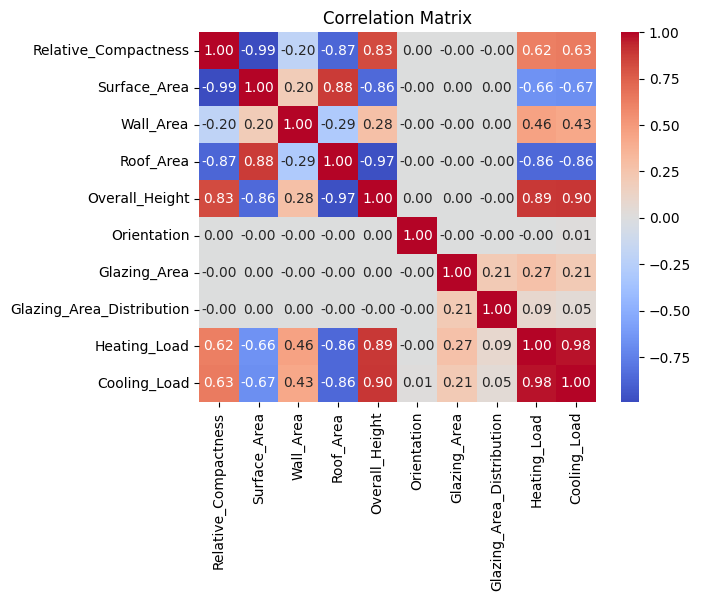

In [8]:
# Correlation heatmap — captures both feature-target signal and multicollinearity in one view
# Scatter plots skipped: given the discrete simulation structure, the correlation matrix
# tells us everything scatter plots would show
sns.heatmap(data=data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

<b><u>Correlation Matrix — Key Findings</u></b><br><br>

<b>Feature-target signal (Y1):</b>
<li>Overall_Height: <b>+0.89</b> — dominant predictor</li>
<li>Roof_Area: <b>−0.86</b> — strong negative; taller buildings have smaller roof footprints</li>
<li>Surface_Area: −0.66, Relative_Compactness: +0.62 — moderate</li>
<li>Orientation: <b>~0.00</b> — zero signal, drop immediately</li>

<br><b>Multicollinearity problem:</b><br>
X1, X2, X4, X5 form a <b>three-way geometry cluster</b> — all derived from the same underlying building shape:
<li>Relative_Compactness ↔ Surface_Area: <b>−0.99</b></li>
<li>Roof_Area ↔ Overall_Height: <b>−0.97</b></li>

Including all four would make X^T X near-singular, destabilizing the normal equation and inflating coefficient variance. We keep <b>Overall_Height</b> as the single representative — it has the highest target correlation of the group.

<hr>
<h3>3. Feature Selection</h3>

In [9]:
# Features kept:
# - Overall_Height: strongest predictor, representative of the X1/X2/X4/X5 geometry cluster
# - Wall_Area: moderate target correlation (0.46), largely independent from the geometry cluster
# - Glazing_Area: weak (0.27) but independent signal
# - Glazing_Area_Distribution: near-zero (0.09) but retained — Lasso would likely zero this out
#
# Features dropped:
# - Relative_Compactness, Surface_Area, Roof_Area: redundant with Overall_Height
# - Orientation: zero correlation with target

feat_to_keep = ['Wall_Area', 'Overall_Height', 'Glazing_Area', 'Glazing_Area_Distribution']

X = data[feat_to_keep]
y = data['Heating_Load']

X.head()

,Wall_Area,Overall_Height,Glazing_Area,Glazing_Area_Distribution
0,294.0,7.0,0.0,0
1,294.0,7.0,0.0,0
2,294.0,7.0,0.0,0
3,294.0,7.0,0.0,0
4,318.5,7.0,0.0,0


In [10]:
# Hold out 20% as a final test set before any cross-validation or model fitting
# The test set must never influence training decisions — touching it early is data leakage
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

<hr>
<h3>4. Sklearn Baseline — Normal Equation</h3>

Sklearn's <code>LinearRegression</code> solves the closed-form normal equation: <b>w = (X^T X)^-1 X^T y</b><br>
This gives the exact optimal weights in one shot — no iterations, no learning rate.<br><br>

We use this as a <b>reference baseline</b> to validate our from-scratch gradient descent implementation.<br><br>

<b>Cross-validation choice:</b> 10-fold on the training set.<br>
With 768 samples, 10-fold (trains on 90% per fold) gives a lower-bias generalization estimate than 5-fold,
without meaningful cost in variance. The ± std across folds is as important as the mean — it reflects
how sensitive the estimate is to which samples land in each fold.

In [11]:
# Pipeline wraps scaler + model so StandardScaler is fit on train-fold data only inside each CV split
# If we scaled the full dataset before CV, test-fold statistics would leak into the scaler fit
model = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LinearRegression())
])

scores = cross_val_score(model, X_train, y_train, cv=10)
print(scores)
print(f"CV R²: {scores.mean() * 100:.2f}% ± {scores.std():.2f} std")

[0.91582657 0.86378917 0.91585588 0.90291267 0.89690339 0.92322572
 0.92527692 0.91375728 0.90179022 0.93479754]
CV R²: 90.94% ± 0.02 std


In [12]:
# Refit on full training set — CV is for evaluation, not the final model
# Evaluate once on the held-out test set — this is the unbiased final verdict
model.fit(X_train, y_train)
test_score = model.score(X_test, y_test)
print(f'Test R²: {test_score * 100:.2f}%')

Test R²: 89.83%


In [13]:
# RMSE and MAE give error in original units (kWh/m²) — more interpretable than R² alone
# RMSE penalizes large errors more heavily (squared residuals), MAE weights all errors equally
# The RMSE/MAE ratio indicates how much variance there is in error size
y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
print(f'RMSE: {rmse:.4f} kWh/m²')
print(f'MAE:  {mae:.4f} kWh/m²')

RMSE: 3.3508 kWh/m²
MAE:  2.3945 kWh/m²


In [ ]:
"""
Interpretation:
RMSE/MAE ratio ~1.4 — the model has some predictions that are significantly worse than average,
inflating RMSE above MAE. These are likely the tall-building samples where the bimodal
target distribution creates a harder sub-population for a single linear model.

RMSE is ~8.6% and MAE ~6.1% of the Y1 range (6–45 kWh/m²) — both small in absolute terms.

>>> Summary:
The model explains 90% of the variance in heating load using just 4 features.
An RMSE of 3.35 kWh/m² is well below the Y1 standard deviation (~10 kWh/m²),
meaning the model significantly outperforms the null baseline of always predicting the mean.
The RMSE/MAE gap points to a known limitation: a single linear model on a bimodal target
will always underfit one of the two sub-populations.
"""

In [15]:
# Extract coefficients from inside the Pipeline for comparison with GD weights
# Coefficients are on standardized features — magnitudes are directly comparable
lr_model = model.named_steps['lr']
print(f"Intercept (Beta 0):        {lr_model.intercept_:.4f}")
print(f"Coefficients (Beta 1–4):   {lr_model.coef_}")

Intercept (Beta 0):        22.1795
Coefficients (Beta 1–4):   [2.21182943 8.29968947 2.63839895 0.24110737]


In [ ]:
"""
Coefficient interpretation:

Intercept ~22.18 — predicted heating load when all features are at their mean.
Close to the actual Y1 mean (~22.3 kWh/m²). Makes sense.

Overall_Height: 8.30 — by far the dominant predictor, consistent with the 0.89 correlation in EDA.
A 1 std increase in building height drives heating load up by 8.3 kWh/m².

Glazing_Area: 2.64 — more glazing = more heat loss = higher heating load. Physically intuitive.

Wall_Area: 2.21 — more wall surface = more heat loss = higher heating load.

Glazing_Area_Distribution: 0.24 — near zero. Barely contributing.
Lasso would likely drive this coefficient to exactly zero.

All coefficients positive — makes physical sense. More building surface, height,
and glazing all increase heating demand.
"""

<hr>
<h3>5. From-Scratch Implementation — Gradient Descent</h3>

Instead of inverting X^T X, gradient descent minimizes MSE <b>iteratively</b> by stepping
opposite to the gradient of the loss at each iteration:

<pre>
Forward pass:   ŷ    = X @ w
Loss (MSE):     L    = (1/n) ||y - ŷ||²
Gradient:       ∂L/∂w = -(2/n) X^T (y - ŷ)
Update:         w    = w - α * ∂L/∂w
</pre>

The bias term is folded into <code>w</code> by prepending a column of ones to X — no separate bias variable needed.<br><br>
<b>Note:</b> features must be normalized before passing to GD. The normal equation is scale-invariant;
gradient descent is not — unequal feature scales cause slow or unstable convergence.

In [17]:
import sys
sys.path.append('..')

from models.supervised.regression import LinearRegressionGD

# Fit scaler on train only — using fit_transform on test would leak test statistics into normalization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model_gd = LinearRegressionGD(lr=0.01, n_iter=1000)
model_gd.fit(X_train_scaled, y_train)
print(f"Test R²: {model_gd.score(X_test_scaled, y_test) * 100:.2f}%")

Fitting Model:  45%|████▌     | 451/1000 [00:00<00:00, 60032.72it/s]

Early stopping at iteration 451 — loss change below 1e-06
Test R²: 89.83%


<h3>6. Validation — GD vs Sklearn</h3>

If the implementation is correct, gradient descent should converge to the same solution
as the normal equation. Small numerical differences are expected — the normal equation
is exact; GD is iterative and stops when improvement falls below <code>tol=1e-6</code>.

In [18]:
coef_gd = model_gd.get_coeff()

print("          {'Intercept':>10}  {'Coeff 1':>10}  {'Coeff 2':>10}  {'Coeff 3':>10}  {'Coeff 4':>10}")
print(f"GD:       {coef_gd['intercept']:>10.4f}  {coef_gd['coefficients'][0]:>10.4f}  {coef_gd['coefficients'][1]:>10.4f}  {coef_gd['coefficients'][2]:>10.4f}  {coef_gd['coefficients'][3]:>10.4f}")
print(f"sklearn:  {lr_model.intercept_:>10.4f}  {lr_model.coef_[0]:>10.4f}  {lr_model.coef_[1]:>10.4f}  {lr_model.coef_[2]:>10.4f}  {lr_model.coef_[3]:>10.4f}")

          {'Intercept':>10}  {'Coeff 1':>10}  {'Coeff 2':>10}  {'Coeff 3':>10}  {'Coeff 4':>10}
GD:          22.1771      2.2158      8.2957      2.6374      0.2422
sklearn:     22.1795      2.2118      8.2997      2.6384      0.2411


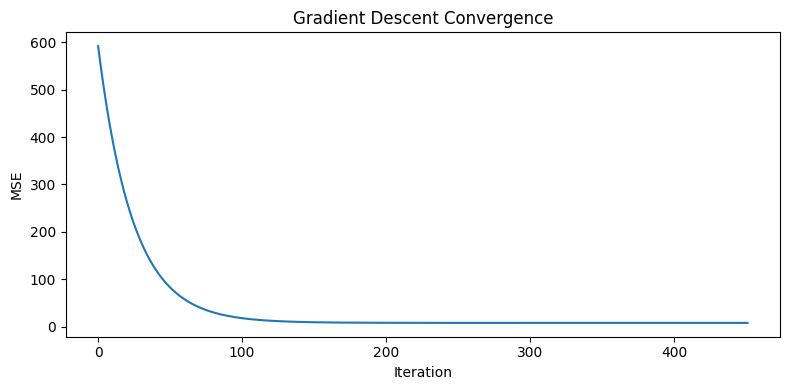

Converged at iteration 452 / 1000
Final training MSE: 8.5391


In [19]:
# Loss curve — confirms the model converged rather than just getting lucky with the score
# Expected shape: steep initial drop (large gradients early), asymptotic flattening near the minimum
# Early stopping halts the loop when per-iteration MSE change drops below tol (1e-6)
plt.figure(figsize=(8, 4))
plt.plot(model_gd.loss_history)
plt.xlabel('Iteration')
plt.ylabel('MSE')
plt.title('Gradient Descent Convergence')
plt.tight_layout()
plt.show()

print(f"Converged at iteration {len(model_gd.loss_history)} / {model_gd.n_iter}")
print(f"Final training MSE: {model_gd.loss_history[-1]:.4f}")